Day 16 Hyperparamter tuning

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

# Load dataset
X, y = load_iris(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Grid Search
grid_params = {
    "C": [0.1, 1, 10],
    "gamma": [0.1, 0.01, 0.001],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(SVC(), grid_params, cv=5)
grid.fit(X_train, y_train)

print("Best Grid Parameters:", grid.best_params_)
print("Best Grid Score:", grid.best_score_)

# Random Search
random_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["rbf", "linear"]
}

random = RandomizedSearchCV(
    SVC(),
    random_params,
    n_iter=5,
    cv=5,
    random_state=42
)
random.fit(X_train, y_train)

print("Best Random Parameters:", random.best_params_)
print("Best Random Score:", random.best_score_)

Day 17 Model Evaluation Metrics

In [1]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [4]:
# Actual and predicted labels
y_true = [0, 1, 1, 0, 1, 0, 1, 1]
y_pred = [0, 1, 0, 0, 1, 0, 1, 1]

# Predicted probabilities
y_scores = [0.10, 0.90, 0.40, 0.20, 0.85, 0.15, 0.95, 0.80]

In [5]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_scores)

print("Precision:", precision)
print("Recall:", recall)
print("AUC:", auc)

Precision: 1.0
Recall: 0.8
AUC: 1.0


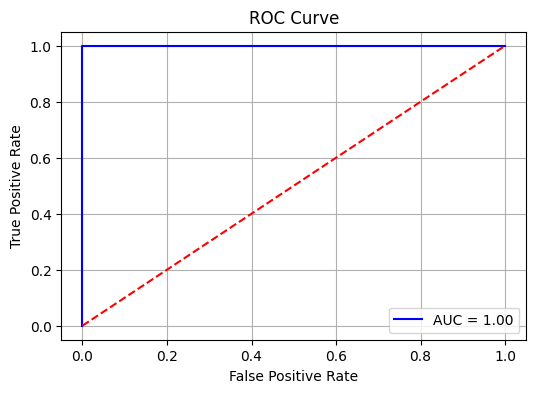

In [6]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Day 18 Bias Variance trade off and regularization

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

# Train and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print("-" * 30)
    print(f"MSE : {mse:.2f}")
    print(f"R2 Score : {r2:.2f}")


Linear Regression
------------------------------
MSE : 2900.19
R2 Score : 0.45

Ridge Regression
------------------------------
MSE : 3077.42
R2 Score : 0.42

Lasso Regression
------------------------------
MSE : 2798.19
R2 Score : 0.47


Day 18 Joblib and pickle

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save model using pickle
with open("iris_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

# Load model
with open("iris_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Make prediction
prediction = loaded_model.predict(X_test[:5])
print("Predictions:", prediction)

Model saved successfully!
Predictions: [1 0 2 1 1]


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save model using joblib
joblib.dump(model, "iris_model.joblib")
print("Model saved successfully!")

# Load model
loaded_model = joblib.load("iris_model.joblib")

# Make prediction
prediction = loaded_model.predict(X_test[:5])
print("Predictions:", prediction)

Model saved successfully!
Predictions: [1 0 2 1 1]


Day 19 Fast API and Model Serving point

In [10]:
# Day 4 - Train and Save Iris Model

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save trained model
joblib.dump(model, "iris_model.joblib")

print("✅ Model trained and saved successfully!")

✅ Model trained and saved successfully!


Day 20 1M Capstone: Sentiment Classifier — Deploy & Document

In [11]:
# Day 5 - Load Model and Predict

import joblib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Load saved model
model = joblib.load("iris_model.joblib")

# Predict
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2f}")

print("\nFirst Five Predictions:")
for i in range(5):
    print(
        f"Sample {i+1}: "
        f"Predicted = {iris.target_names[predictions[i]]}, "
        f"Actual = {iris.target_names[y_test[i]]}"
    )

Model Accuracy: 1.00

First Five Predictions:
Sample 1: Predicted = versicolor, Actual = versicolor
Sample 2: Predicted = setosa, Actual = setosa
Sample 3: Predicted = virginica, Actual = virginica
Sample 4: Predicted = versicolor, Actual = versicolor
Sample 5: Predicted = versicolor, Actual = versicolor
